In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [86]:
df = pd.read_csv('G:\Machine Learning Projects\Project_07_Customer_Churn_Prediction\data.csv')

print("=" * 60)
print("STEP 1: Data Loaded")
print("=" * 60)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows: \n{df.head()}")


STEP 1: Data Loaded
Dataset Shape: (7043, 21)

First 5 rows: 
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   



In [87]:
print("\n" + "=" * 60)
print("STEP 2: Exploratory Data Analysis (EDA)")
print("=" * 60)

missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\nMissing Values: \n{missing}")




STEP 2: Exploratory Data Analysis (EDA)

Missing Values: 
Series([], dtype: int64)



Target distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.54%


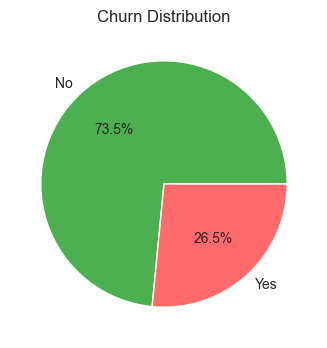

In [88]:
print(f"\nTarget distribution (Churn):")
print(df['Churn'].value_counts())
print(f"Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.2f}%")

plt.figure(figsize=(8, 4))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4CaF50', "#FF6B6B"])
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()

In [89]:
print("=" * 60)
print("STEP 3: Data Preprocessing")
print("=" * 60)

# Drop 'customerID' column as it is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

# Convert 'TotalCharges' to numeric, coerce errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values in 'TotalCharges' by filling with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Covert 'Churn' target to binary (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('Churn')

print(f"\nCategorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numeric_cols}")

STEP 3: Data Preprocessing

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [90]:
# One-hot encode categorical variables
# IMPORTANT: Only 'Contract' has a natural order (Month-to-month < One year < Two year)
# All other categories are nominal (no order) and need One-Hot Encoding

from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("=" * 60)
print("STEP 6: Encoding Categorical Variables")
print("=" * 60)

# Define which columns are ordinal (have a natural order)
ordinal_cols = ['Contract']  # Only Contract is ordinal

# All other categorical columns are nominal (no order)
nominal_cols = [col for col in categorical_cols if col not in ordinal_cols]

label_encoders = {}

# 1. Encode ORDINAL columns (Contract) with LabelEncoder
print("\nEncoding Ordinal Columns (LabelEncoder):")
for col in ordinal_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. Encode NOMINAL columns with One-Hot Encoding
print("\nEncoding Nominal Columns (One-Hot Encoding):")
print(f"  Columns: {nominal_cols}")
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Store the new one-hot column names so you can save them later (optional)
onehot_column_names = [col for col in df.columns if any(nom in col for nom in nominal_cols)]
label_encoders['onehot_columns'] = onehot_column_names  # Save for metadata

print(f"\n✅ All categorical columns encoded!")
print(f"   - Ordinal (LabelEncoder): {ordinal_cols}")
print(f"   - Nominal (One-Hot): {nominal_cols}")
print(f"   - Total columns now: {df.shape[1]}")
print("=" * 60)

STEP 6: Encoding Categorical Variables

Encoding Ordinal Columns (LabelEncoder):
  Contract: {'Month-to-month': np.int64(0), 'One year': np.int64(1), 'Two year': np.int64(2)}

Encoding Nominal Columns (One-Hot Encoding):
  Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']

✅ All categorical columns encoded!
   - Ordinal (LabelEncoder): ['Contract']
   - Nominal (One-Hot): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'PaymentMethod']
   - Total columns now: 30


In [91]:
print("=" * 60)
print("STEP 4: Correlation Analysis")
print("=" * 60)

correlations = df.corr()['Churn'].sort_values(ascending=False)
print(f"\nTop features correlated with Churn: ")
print(correlations.head(10))

print("\nFeatures with lowest correlation (drop if < 0.05):")
print(correlations.tail(10))

low_corr_cols = correlations[abs(correlations) < 0.05].index.tolist()
print(f"\nColumns with very low correlation (<0.05): {low_corr_cols}")

df = df.drop(low_corr_cols, axis=1)

STEP 4: Correlation Analysis

Top features correlated with Churn: 
Churn                             1.000000
InternetService_Fiber optic       0.308020
PaymentMethod_Electronic check    0.301919
MonthlyCharges                    0.193356
PaperlessBilling_Yes              0.191825
SeniorCitizen                     0.150889
StreamingTV_Yes                   0.063228
StreamingMovies_Yes               0.061382
MultipleLines_Yes                 0.040102
PhoneService_Yes                  0.011942
Name: Churn, dtype: float64

Features with lowest correlation (drop if < 0.05):
TotalCharges                           -0.199037
OnlineBackup_No internet service       -0.227890
OnlineSecurity_No internet service     -0.227890
DeviceProtection_No internet service   -0.227890
InternetService_No                     -0.227890
TechSupport_No internet service        -0.227890
StreamingTV_No internet service        -0.227890
StreamingMovies_No internet service    -0.227890
tenure                         

In [92]:
print("=" * 60)
print("STEP 5: Removing Outliers (IQR Method)")
print("=" * 60)

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

original_len = len(df)
print(f"\nOutliers in numeric columns:")
for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers")

outlier_indices = set()
for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    outlier_indices.update(outliers.index)
df_clean = df.drop(outlier_indices)
print(f"\nRemoved {original_len - len(df_clean)} total outlier rows")
print(f"Clean dataset shape: {df_clean.shape}")


STEP 5: Removing Outliers (IQR Method)

Outliers in numeric columns:
SeniorCitizen: 1142 outliers
tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers

Removed 1142 total outlier rows
Clean dataset shape: (5901, 26)


In [93]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
print(f"Feature matrix shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"Churn rate in cleaned data: {y.mean()*100:.2f}%")


Feature matrix shape: (5901, 25)
Target Shape: (5901,)
Churn rate in cleaned data: 23.61%


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Samples : {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")
print(f"Training Churn Rate: {y_train.mean()*100:.2f}%, Testing Churn Rate: {y_test.mean()*100:.2f}%")


Training Samples : 4720, Testing Samples: 1181
Training Churn Rate: 23.60%, Testing Churn Rate: 23.62%


In [95]:
print("=" * 60)
print("STEP 8: Training Random Forest with Class Weights")
print("=" *60)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print(f"Class weights: {class_weight_dict}")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

STEP 8: Training Random Forest with Class Weights
Class weights: {np.int64(0): np.float64(0.6544647809206877), np.int64(1): np.float64(2.118491921005386)}


,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
print("\n" + "="*60)
print("STEP 9: Model Evaluation")
print("="*60)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

print("\n--- TRAINING SET PERFORMANCE ---")
print(f"Accuracy : {accuracy_score(y_train, y_pred_train): .4f}")
print(f"Precision: {precision_score(y_train, y_pred_train): .4f}")
print(f"Recall : {recall_score(y_train, y_pred_train): .4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train): .4f}")



STEP 9: Model Evaluation

--- TRAINING SET PERFORMANCE ---
Accuracy :  0.8756
Precision:  0.6701
Recall :  0.9318
F1-Score:  0.7796



--- TEST SET PERFORMANCE ---
Accuracy:  0.8095
Precision: 0.5785
Recall:    0.7133
F1-Score:  0.6388
ROC-AUC:   0.8556

Classification Report (Test Set):
              precision    recall  f1-score   support

    No Churn       0.90      0.84      0.87       902
       Churn       0.58      0.71      0.64       279

    accuracy                           0.81      1181
   macro avg       0.74      0.78      0.75      1181
weighted avg       0.83      0.81      0.82      1181



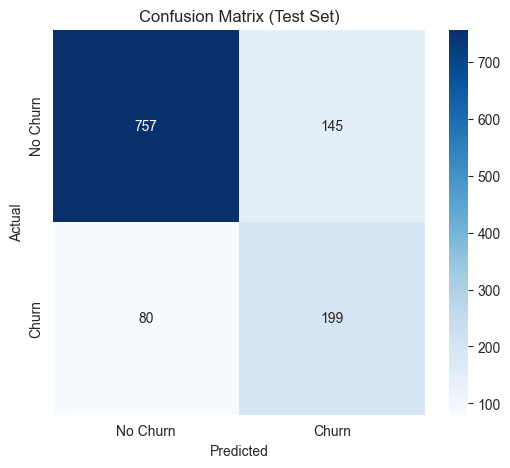

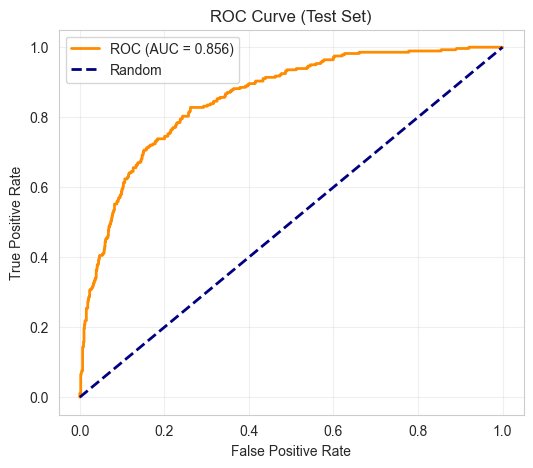


STEP 10: Feature Importance

Top 10 Most Important Features for Churn Prediction:
                           Feature  Importance
2                         Contract    0.175323
1                           tenure    0.174946
4                     TotalCharges    0.155902
3                   MonthlyCharges    0.124135
7      InternetService_Fiber optic    0.059254
23  PaymentMethod_Electronic check    0.047387
10              OnlineSecurity_Yes    0.032043
16                 TechSupport_Yes    0.022970
21            PaperlessBilling_Yes    0.021844
5                      Partner_Yes    0.017981


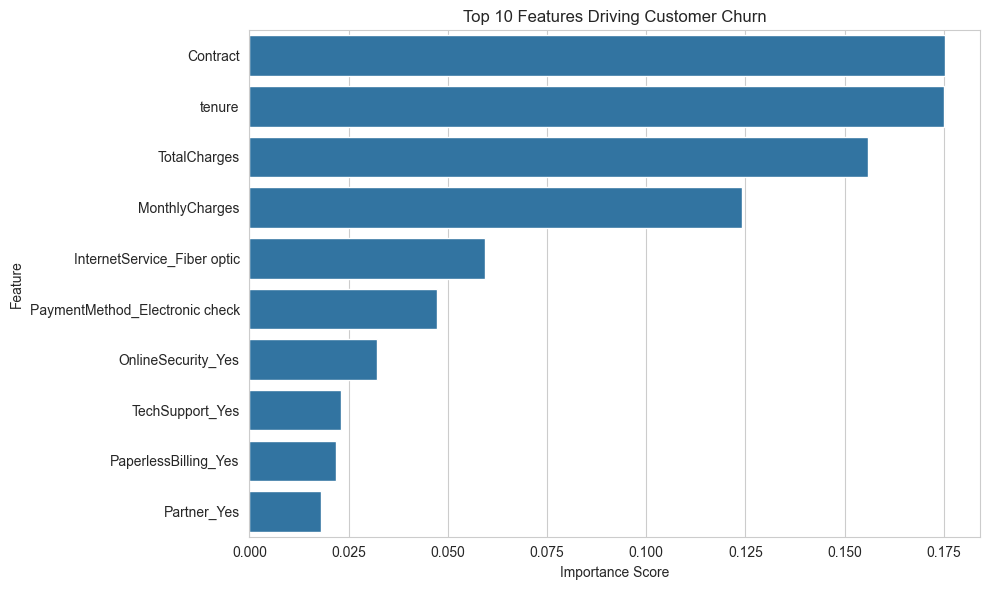


STEP 11: Saving Model & Artifacts
✅ Model saved to 'models/churn_model.pkl'
✅ Scaler saved to 'models/scaler.pkl'
✅ Label encoders saved to 'models/label_encoders.pkl'
✅ Metadata saved to 'models/metadata.pkl'

✅ PROJECT COMPLETED SUCCESSFULLY!
Dataset: Customer Churn (Telecom)
Total samples: 5901
Features used: 25
Model: Random Forest Classifier (with class weights)
Test Set Performance:
  - Accuracy:  0.8095
  - Precision: 0.5785
  - Recall:    0.7133
  - F1-Score:  0.6388
  - ROC-AUC:   0.8556


In [97]:
print("\n--- TEST SET PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
auc = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('roc_curve.png')
plt.show()

# --------------------------
# STEP 10: Feature Importance
# --------------------------
print("\n" + "="*60)
print("STEP 10: Feature Importance")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features for Churn Prediction:")
print(feature_importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
plt.title('Top 10 Features Driving Customer Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# --------------------------
# STEP 11: Save Model & Artifacts
# --------------------------
print("\n" + "="*60)
print("STEP 11: Saving Model & Artifacts")
print("="*60)

os.makedirs('models', exist_ok=True)

# Save model
joblib.dump(model, 'models/churn_model.pkl')

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')

# Save label encoders
joblib.dump(label_encoders, 'models/label_encoders.pkl')

# Save metadata
metadata = {
    'feature_names': X.columns.tolist(),
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'target_name': 'Churn'
}
joblib.dump(metadata, 'models/metadata.pkl')

print("✅ Model saved to 'models/churn_model.pkl'")
print("✅ Scaler saved to 'models/scaler.pkl'")
print("✅ Label encoders saved to 'models/label_encoders.pkl'")
print("✅ Metadata saved to 'models/metadata.pkl'")

# --------------------------
# STEP 12: Summary
# --------------------------
print("\n" + "="*60)
print("✅ PROJECT COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"Dataset: Customer Churn (Telecom)")
print(f"Total samples: {len(df_clean)}")
print(f"Features used: {len(X.columns)}")
print(f"Model: Random Forest Classifier (with class weights)")
print(f"Test Set Performance:")
print(f"  - Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}")
print(f"  - Precision: {precision_score(y_test, y_pred_test):.4f}")
print(f"  - Recall:    {recall_score(y_test, y_pred_test):.4f}")
print(f"  - F1-Score:  {f1_score(y_test, y_pred_test):.4f}")
print(f"  - ROC-AUC:   {roc_auc_score(y_test, y_proba_test):.4f}")